# 02. EDA: Fail Pattern Analysis
Pass/Fail 간 차이가 큰 측정 feature 후보를 효과크기와 Mann-Whitney U 검정으로 선별합니다. 다중검정은 Benjamini-Hochberg FDR로 보정합니다.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))
from src.secom_analysis import load_secom, data_quality_reports, compare_pass_fail

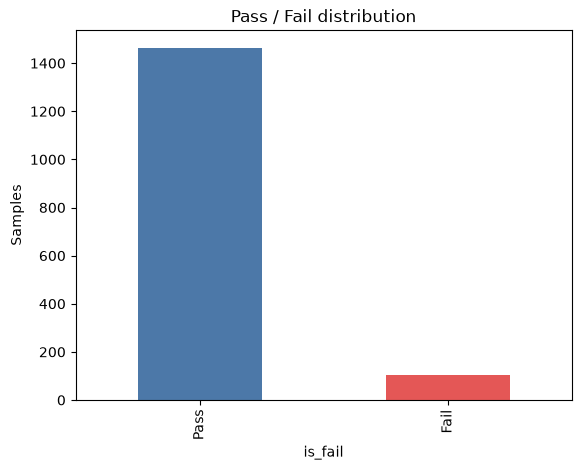

In [2]:
X, labels = load_secom(project_root / 'data/raw')
summary, missing, constants, drops, kept = data_quality_reports(X, labels['is_fail'])
counts = labels['is_fail'].value_counts().sort_index()
ax = counts.rename(index={0: 'Pass', 1: 'Fail'}).plot.bar(color=['#4C78A8', '#E45756'])
ax.set(title='Pass / Fail distribution', ylabel='Samples')
plt.show()

In [3]:
by_diff, by_test = compare_pass_fail(X, labels['is_fail'], kept)
report_dir = project_root / 'reports'
report_dir.mkdir(exist_ok=True)
by_diff.to_csv(report_dir / 'top_features_by_mean_diff.csv', index=False)
by_test.to_csv(report_dir / 'top_features_by_stat_test.csv', index=False)
display(by_diff.head(20))
display(by_test.head(20))

,feature,pass_n,fail_n,pass_mean,fail_mean,mean_diff,standardized_mean_diff,mannwhitney_u,p_value,abs_standardized_mean_diff
54,feature_59,1456,104,2.563464,8.515123,5.951659,0.590135,104791.5,5.678638e-11,0.590135
93,feature_103,1461,104,-0.009913,-0.008053,0.001860,0.571259,101524.0,9.550430e-09,0.571259
116,feature_129,1454,104,-0.587959,-0.082641,0.505318,0.477981,93602.0,4.831540e-05,0.477981
26,feature_28,1462,103,69.598032,68.101406,-1.496627,-0.444390,57659.0,6.955946e-05,0.444390
388,feature_510,1461,104,54.440591,74.347949,19.907358,0.427267,96642.5,3.452612e-06,0.427267
254,feature_316,1462,104,6.001261,5.635604,-0.365657,-0.384043,59398.5,1.907070e-04,0.384043
111,feature_124,1454,104,15.791836,15.834808,0.042971,0.377150,91043.0,4.928453e-04,0.377150
112,feature_125,1454,104,1.191248,1.096981,-0.094268,-0.368875,61570.5,1.538907e-03,0.368875
108,feature_121,1454,104,15.794161,15.828077,0.033916,0.349915,88674.0,3.179769e-03,0.349915
109,feature_122,1454,104,3.917336,3.633510,-0.283826,-0.346141,62371.5,2.823943e-03,0.346141


,feature,pass_n,fail_n,pass_mean,fail_mean,mean_diff,standardized_mean_diff,mannwhitney_u,p_value,fdr_bh
54,feature_59,1456,104,2.563464,8.515123,5.951659,0.590135,104791.5,5.678638e-11,2.532672e-08
93,feature_103,1461,104,-0.009913,-0.008053,0.001860,0.571259,101524.0,9.550430e-09,2.129746e-06
203,feature_247,781,71,0.051741,0.071328,0.019587,0.297150,37410.5,1.071653e-06,1.330082e-04
390,feature_519,781,71,11.393324,15.414710,4.021385,0.266983,37368.5,1.192899e-06,1.330082e-04
388,feature_510,1461,104,54.440591,74.347949,19.907358,0.427267,96642.5,3.452612e-06,3.079730e-04
367,feature_477,1457,104,6.105094,8.398982,2.293888,0.169442,94143.0,3.500084e-05,2.601729e-03
179,feature_205,1457,104,8.884743,11.367019,2.482277,0.191230,93836.5,4.717189e-05,2.693584e-03
116,feature_129,1454,104,-0.587959,-0.082641,0.505318,0.477981,93602.0,4.831540e-05,2.693584e-03
26,feature_28,1462,103,69.598032,68.101406,-1.496627,-0.444390,57659.0,6.955946e-05,3.447057e-03
31,feature_33,1462,104,8.931262,9.368187,0.436926,0.226407,92836.0,1.613608e-04,6.579027e-03


C:\Users\user\AppData\Local\Temp\ipykernel_30656\973091806.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X.assign(is_fail=labels['is_fail']).boxplot(column=feature, by='is_fail', ax=ax)
C:\Users\user\AppData\Local\Temp\ipykernel_30656\973091806.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X.assign(is_fail=labels['is_fail']).boxplot(column=feature, by='is_fail', ax=ax)
C:\Users\user\AppData\Local\Temp\ipykernel_30656\973091806.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of ca

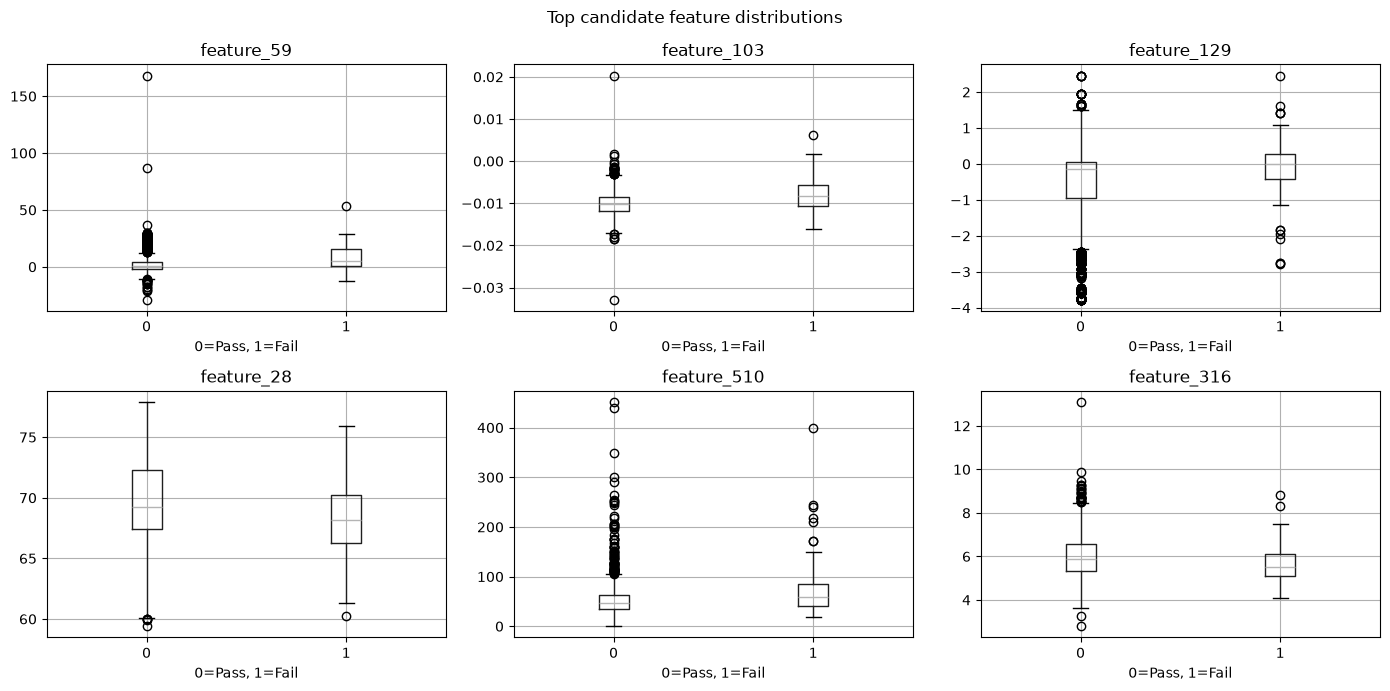

In [4]:
top_features = by_diff.head(6)['feature']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for feature, ax in zip(top_features, axes.ravel()):
    X.assign(is_fail=labels['is_fail']).boxplot(column=feature, by='is_fail', ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('0=Pass, 1=Fail')
fig.suptitle('Top candidate feature distributions')
fig.tight_layout()
plt.show()